In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import kagglehub
import cv2
import os
from PIL import Image
import numpy as np

# تحميل البيانات
import kagglehub
path = kagglehub.dataset_download("hungle3401/faceforensics")

# استخراج الفريمز
real_path = path + "/FF++/real"
fake_path = path + "/FF++/fake"

output_real = "/content/dataset/real"
output_fake = "/content/dataset/fake"
os.makedirs(output_real, exist_ok=True)
os.makedirs(output_fake, exist_ok=True)

def extract_frames(video_folder, output_folder, frames_per_video=5):
    videos = os.listdir(video_folder)
    total = 0
    for video in videos:
        cap = cv2.VideoCapture(video_folder + "/" + video)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        interval = total_frames // frames_per_video
        for i in range(frames_per_video):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (224, 224))
                name = f"{video[:-4]}_frame{i}.jpg"
                cv2.imwrite(output_folder + "/" + name, frame)
                total += 1
        cap.release()
    print(f"Extracted {total} frames to {output_folder}")

extract_frames(real_path, output_real)
extract_frames(fake_path, output_fake)

# تجهيز البيانات
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder("/content/dataset", transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# تجهيز النموذج
device = torch.device("cpu")
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 2)
model = model.to(device)
criterion = nn.CrossEntropyLoss()

print("Ready!")

Using Colab cache for faster access to the 'faceforensics' dataset.


KeyboardInterrupt: 

In [2]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

print("Training done!")

Epoch 1/10 | Loss: 0.6632 | Acc: 59.94%
Epoch 2/10 | Loss: 0.5462 | Acc: 76.06%
Epoch 3/10 | Loss: 0.4567 | Acc: 79.38%
Epoch 4/10 | Loss: 0.3779 | Acc: 83.44%
Epoch 5/10 | Loss: 0.3082 | Acc: 87.12%
Epoch 6/10 | Loss: 0.2325 | Acc: 90.44%
Epoch 7/10 | Loss: 0.1793 | Acc: 93.12%
Epoch 8/10 | Loss: 0.1399 | Acc: 95.06%
Epoch 9/10 | Loss: 0.1307 | Acc: 94.56%
Epoch 10/10 | Loss: 0.1132 | Acc: 95.62%
Training done!


In [4]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 72.25%


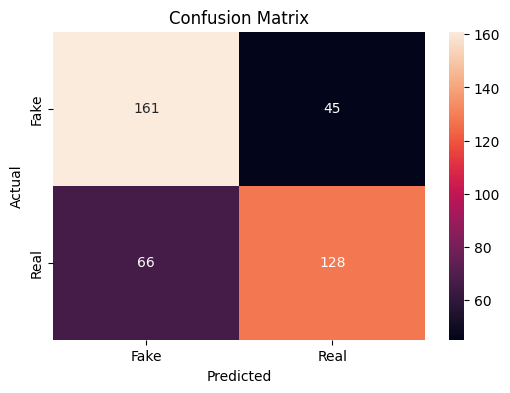

              precision    recall  f1-score   support

        Fake       0.71      0.78      0.74       206
        Real       0.74      0.66      0.70       194

    accuracy                           0.72       400
   macro avg       0.72      0.72      0.72       400
weighted avg       0.72      0.72      0.72       400



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/confusion_matrix.png')
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

In [7]:
import os
os.makedirs("/content/models", exist_ok=True)
torch.save(model.state_dict(), "/content/models/mobilenetv2_v2.pth")
print("Model v2 saved!")

Model v2 saved!


In [8]:
import io

def evaluate_robustness(model, test_loader, device, noise_level=0, jpeg_quality=100):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(len(images)):
                img = images[i].numpy().transpose(1, 2, 0)
                img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
                img = np.clip(img * 255, 0, 255).astype(np.uint8)
                pil_img = Image.fromarray(img)

                if jpeg_quality < 100:
                    buffer = io.BytesIO()
                    pil_img.save(buffer, format="JPEG", quality=jpeg_quality)
                    buffer.seek(0)
                    pil_img = Image.open(buffer)

                if noise_level > 0:
                    img_arr = np.array(pil_img).astype(np.float32)
                    noise = np.random.normal(0, noise_level, img_arr.shape)
                    img_arr = np.clip(img_arr + noise, 0, 255).astype(np.uint8)
                    pil_img = Image.fromarray(img_arr)

                transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406],
                                         [0.229, 0.224, 0.225])
                ])
                images[i] = transform(pil_img)

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

print("Robustness Test Results (V2):")
print(f"No degradation:   {evaluate_robustness(model, test_loader, device):.2f}%")
print(f"JPEG Quality 50:  {evaluate_robustness(model, test_loader, device, jpeg_quality=50):.2f}%")
print(f"JPEG Quality 20:  {evaluate_robustness(model, test_loader, device, jpeg_quality=20):.2f}%")
print(f"Noise level 10:   {evaluate_robustness(model, test_loader, device, noise_level=10):.2f}%")
print(f"Noise level 25:   {evaluate_robustness(model, test_loader, device, noise_level=25):.2f}%")

Robustness Test Results (V2):
No degradation:   73.00%
JPEG Quality 50:  65.75%
JPEG Quality 20:  55.50%
Noise level 10:   61.00%
Noise level 25:   48.50%


In [12]:
import gradio as gr
import torch
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image

model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(image):
    if image is None:
        return None
    img = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
    return {
        "🔴 Fake": round(probs[0][0].item(), 3),
        "🟢 Real": round(probs[0][1].item(), 3)
    }

def predict_video(video_path):
    if video_path is None:
        return None
    cap = cv2.VideoCapture(video_path)
    fake_scores = []
    real_scores = []
    frame_count = 0

    while frame_count < 10:  # ناخد أول 10 فريمز بس
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        img = transform(pil_img).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(img)
            probs = torch.softmax(outputs, dim=1)
            fake_scores.append(probs[0][0].item())
            real_scores.append(probs[0][1].item())
        frame_count += 1

    cap.release()

    avg_fake = round(np.mean(fake_scores), 3)
    avg_real = round(np.mean(real_scores), 3)

    return {
        "🔴 Fake": avg_fake,
        "🟢 Real": avg_real
    }

# Image Tab
image_tab = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image or Use Camera"),
    outputs=gr.Label(num_top_classes=2, label="Prediction"),
    title="🖼️ Image Detection",
)

# Video Tab
video_tab = gr.Interface(
    fn=predict_video,
    inputs=gr.Video(label="Upload Video"),
    outputs=gr.Label(num_top_classes=2, label="Prediction"),
    title="🎥 Video Detection",
)

# Combine
app = gr.TabbedInterface(
    [image_tab, video_tab],
    ["🖼️ Image / Camera", "🎥 Video"],
    title="🕵️ Deepfake Detector"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95fc1f876c10653f6a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


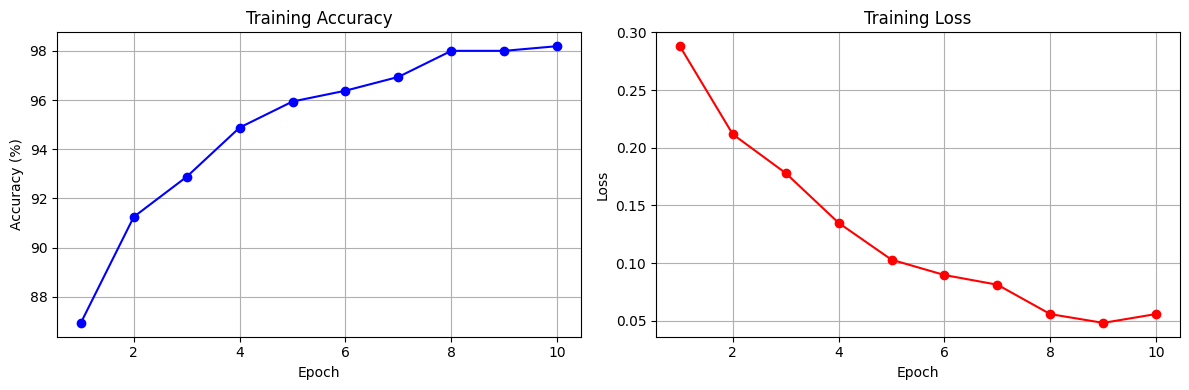

Saved!


In [10]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
v2_acc = [86.94, 91.25, 92.88, 94.88, 95.94, 96.38, 96.94, 98.00, 98.00, 98.19]
v2_loss = [0.2881, 0.2117, 0.1780, 0.1348, 0.1029, 0.0896, 0.0812, 0.0557, 0.0481, 0.0558]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, v2_acc, 'b-o')
ax1.set_title('Training Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.grid(True)

ax2.plot(epochs, v2_loss, 'r-o')
ax2.set_title('Training Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print("Saved!")

In [11]:
from google.colab import files
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>